## Objective
The objective of this project is to build an AdaBoost Regression model for predicting diamond prices using characteristics such as carat, cut, colour, clarity, depth, table, and physical dimensions. The dataset will be examined and prepared before developing the baseline and tuned regression models. Model performance will be evaluated using regression metrics such as MSE, MAE, RMSE, MAPE, and R² score. An appropriate primary evaluation metric should be selected according to the problem statement, target values, and importance of different prediction errors. The selected metric will be used as the scoring measure during hyperparameter tuning and for comparing the baseline and tuned models. Training and testing performance will also be compared using the selected metric to identify possible overfitting. The final model will be selected based on its predictive performance and ability to generalise well to unseen data.

## **Task 1**
- *Import the libraries required for data preparation, modelling, evaluation, and visualisation*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Data Preparation

## **Task 2**

- *Load the dataset and display the first few records*
- *Check the dataset shape, data types, and column names*
- *Check for missing values and duplicate records*

In [2]:
df = pd.read_csv('diamonds_dataset.csv'); df.head()

,carat,cut,color,clarity,depth,table,price,length,width,depth.1
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print('Dataset shape:', df.shape)
print('\nColumn names:'); print(df.columns.tolist())
print('\nDataset information:'); df.info()

Dataset shape: (53772, 10)

Column names:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'length', 'width', 'depth.1']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 53772 entries, 0 to 53771
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53772 non-null  float64
 1   cut      53772 non-null  str    
 2   color    53772 non-null  str    
 3   clarity  53772 non-null  str    
 4   depth    53772 non-null  float64
 5   table    53772 non-null  float64
 6   price    53772 non-null  int64  
 7   length   53772 non-null  float64
 8   width    53772 non-null  float64
 9   depth.1  53772 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.6 MB


In [4]:
print('Missing values in each column:'); print(df.isnull().sum())
print('\nDuplicate records:', df.duplicated().sum())

Missing values in each column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
length     0
width      0
depth.1    0
dtype: int64

Duplicate records: 0


## **Task 3**
- *Separate the predictor variables and the target variable*

In [5]:
X = df.drop('price', axis = 1); y = df['price']
print('Feature dataset shape:', X.shape); print('Target dataset shape:', y.shape)

Feature dataset shape: (53772, 9)
Target dataset shape: (53772,)


## **Task 4**
- *Split the feature and target datasets into training and testing sets*

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
print('Training feature shape:', X_train.shape); print('Testing feature shape:', X_test.shape)

Training feature shape: (43017, 9)
Testing feature shape: (10755, 9)


## **Task 5**
- *Encode the categorical features by fitting the encoder on the training data and applying the same transformation to the testing data*

In [7]:
categorical_columns = X_train.select_dtypes(include = 'object').columns.tolist()
print('Categorical columns:'); print(categorical_columns)

Categorical columns:
['cut', 'color', 'clarity']


In [8]:
encoder = OneHotEncoder(handle_unknown = 'ignore', drop = 'first', sparse_output = False)
preprocessor = ColumnTransformer(transformers = [('encoder', encoder, categorical_columns)], remainder = 'passthrough', verbose_feature_names_out = False)

In [9]:
X_train_encoded = preprocessor.fit_transform(X_train); X_test_encoded = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_train_encoded = pd.DataFrame(X_train_encoded, columns = feature_names, index = X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns = feature_names, index = X_test.index)
print('Encoded training shape:', X_train_encoded.shape); print('Encoded testing shape:', X_test_encoded.shape)

Encoded training shape: (43017, 23)
Encoded testing shape: (10755, 23)


# Model Training

## **Task 6**
- *Build and train a baseline AdaBoost Regressor using the training data*
- *Display the baseline model parameters*

In [10]:
b_model = AdaBoostRegressor( random_state = 42); b_model.fit(X_train_encoded, y_train)
b_model.get_params()

{'estimator': None,
 'learning_rate': 1.0,
 'loss': 'linear',
 'n_estimators': 50,
 'random_state': 42}

## **Task 7**
- *Generate predictions for the training and testing datasets using the baseline model*

In [11]:
b_train_pred = b_model.predict(X_train_encoded); b_test_pred = b_model.predict(X_test_encoded)
print('Training predictions:', b_train_pred[:5]); print('Testing predictions:', b_test_pred[:5])

Training predictions: [ 1108.70618557  6715.1627938  11423.13071009  1108.70618557
  3256.23215249]
Testing predictions: [3431.78378378 3347.14111498 7797.21663156 7248.69618098 2342.40995608]


## **Task 8**
- *Plot the actual and predicted diamond prices for the training and testing datasets using the baseline AdaBoost model*

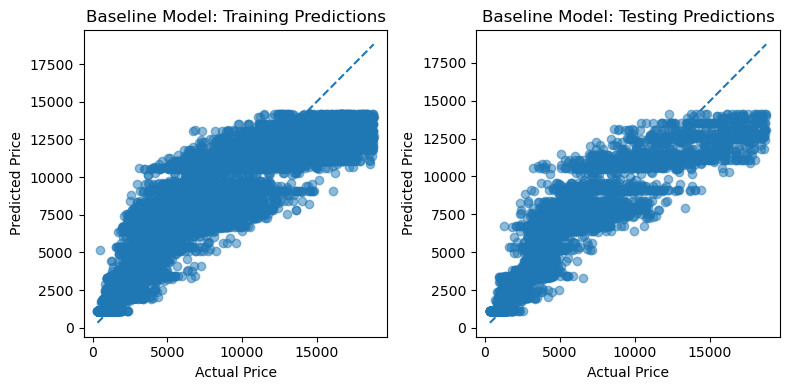

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(y_train, b_train_pred, alpha=0.5)
train_minimum = min(y_train.min(), b_train_pred.min()); train_maximum = max(y_train.max(), b_train_pred.max())
axes[0].plot([train_minimum, train_maximum], [train_minimum, train_maximum], linestyle='--')
axes[0].set_xlabel('Actual Price'); axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Baseline Model: Training Predictions')
axes[1].scatter(y_test, b_test_pred, alpha=0.5)
test_minimum = min(y_test.min(), b_test_pred.min()); test_maximum = max(y_test.max(), b_test_pred.max())
axes[1].plot([test_minimum, test_maximum], [test_minimum, test_maximum], linestyle='--')
axes[1].set_xlabel('Actual Price'); axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Baseline Model: Testing Predictions')
plt.tight_layout()
plt.show()

## **Task 9**
- *Plot the actual and predicted diamond prices for the first 50 testing records using the baseline model*

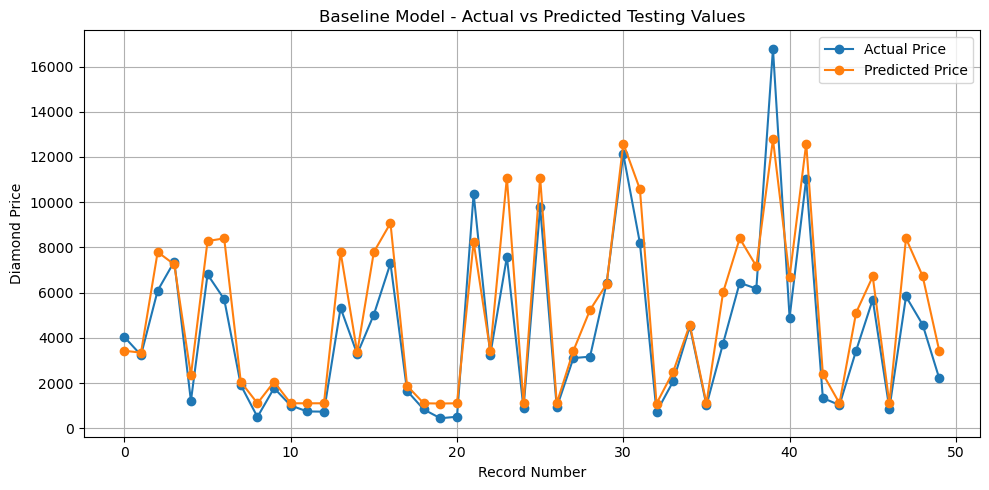

In [13]:
test_actual = y_test.reset_index(drop = True)[:50]
baseline_test_predicted = b_test_pred[:50]
plt.figure(figsize = (10, 5))
plt.plot(test_actual, marker = 'o', label = 'Actual Price')
plt.plot(baseline_test_predicted, marker = 'o', label = 'Predicted Price')
plt.xlabel('Record Number'); plt.ylabel('Diamond Price')
plt.title('Baseline Model - Actual vs Predicted Testing Values')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Model Interpretation

## **Task 10**
- *Evaluate the baseline model using MSE, MAE, RMSE, MAPE, and R² score for the training and testing datasets*

In [14]:
b_train_mse = mean_squared_error(y_train, b_train_pred); b_test_mse = mean_squared_error(y_test, b_test_pred)
b_train_mae = mean_absolute_error(y_train, b_train_pred); b_test_mae = mean_absolute_error(y_test, b_test_pred)
b_train_rmse = np.sqrt(b_train_mse); b_test_rmse = np.sqrt(b_test_mse)
b_train_mape = mean_absolute_percentage_error(y_train, b_train_pred) * 100
b_test_mape = mean_absolute_percentage_error(y_test, b_test_pred) * 100
b_train_r2 = r2_score(y_train, b_train_pred); b_test_r2 = r2_score(y_test, b_test_pred)
print('Baseline Training MSE:', round(b_train_mse, 2)); print('Baseline Testing MSE:', round(b_test_mse, 2))
print('\nBaseline Training MAE:', round(b_train_mae, 2)); print('Baseline Testing MAE:', round(b_test_mae, 2))
print('\nBaseline Training RMSE:', round(b_train_rmse, 2)); print('Baseline Testing RMSE:', round(b_test_rmse, 2))
print('\nBaseline Training MAPE:', round(b_train_mape, 2), '%'); print('Baseline Testing MAPE:', round(b_test_mape, 2), '%')
print('\nBaseline Training R² Score:', round(b_train_r2, 3)); print('Baseline Testing R² Score:', round(b_test_r2, 3))

Baseline Training MSE: 2484961.76
Baseline Testing MSE: 2524837.8

Baseline Training MAE: 1106.02
Baseline Testing MAE: 1113.97

Baseline Training RMSE: 1576.38
Baseline Testing RMSE: 1588.97

Baseline Training MAPE: 41.97 %
Baseline Testing MAPE: 42.28 %

Baseline Training R² Score: 0.844
Baseline Testing R² Score: 0.837


## **Task 11** 
- *Calculate the training–testing performance gap of the baseline AdaBoost model using the selected evaluation metric*

In [15]:
b_rmse_gap = abs(b_test_rmse - b_train_rmse)
print('Baseline RMSE Gap:', round(b_rmse_gap, 2))

Baseline RMSE Gap: 12.6


## **Task 12**

- *Identify and visualise the 5 most influential features used by the baseline model*

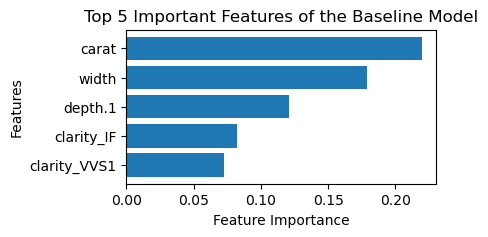

In [16]:
b_feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': b_model.feature_importances_})
b_top_features = b_feature_importance.sort_values(by = 'Importance', ascending = False).head(5)
plt.figure(figsize = (4, 2))
plt.barh(b_top_features['Feature'][::-1], b_top_features['Importance'][::-1])
plt.xlabel('Feature Importance'); plt.ylabel('Features'); plt.title('Top 5 Important Features of the Baseline Model')
plt.show()

# Hyperparameter Tuning

## **Task 13**
- *Define suitable values for `n_estimators`, `learning_rate`, and `loss`*
- *Select an appropriate scoring metric according to the problem statement and model objective*
- *Tune the AdaBoost Regressor using five-fold cross-validation and the selected scoring metric and display the best hyperparameters and best cross-validation score**
- *Select and train the best estimator as the final AdaBoost model*

In [17]:
parameter_grid = {'n_estimators': [50, 100], 'learning_rate': [0.5, 1, 1.5], 'loss': ['linear', 'square']}
tuning_model = AdaBoostRegressor( random_state = 42)
grid_search = GridSearchCV(estimator = tuning_model, param_grid = parameter_grid, scoring = 'neg_root_mean_squared_error', cv = 5, n_jobs = 1, verbose = 10)
grid_search.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5; 1/12] START learning_rate=0.5, loss=linear, n_estimators=50............
[CV 1/5; 1/12] END learning_rate=0.5, loss=linear, n_estimators=50;, score=-1514.956 total time=   1.6s
[CV 2/5; 1/12] START learning_rate=0.5, loss=linear, n_estimators=50............
[CV 2/5; 1/12] END learning_rate=0.5, loss=linear, n_estimators=50;, score=-1459.666 total time=   1.7s
[CV 3/5; 1/12] START learning_rate=0.5, loss=linear, n_estimators=50............
[CV 3/5; 1/12] END learning_rate=0.5, loss=linear, n_estimators=50;, score=-1412.462 total time=   1.7s
[CV 4/5; 1/12] START learning_rate=0.5, loss=linear, n_estimators=50............
[CV 4/5; 1/12] END learning_rate=0.5, loss=linear, n_estimators=50;, score=-1490.559 total time=   1.7s
[CV 5/5; 1/12] START learning_rate=0.5, loss=linear, n_estimators=50............
[CV 5/5; 1/12] END learning_rate=0.5, loss=linear, n_estimators=50;, score=-1460.375 total time=   1.3s
[CV 1/5; 2/12]

,estimator,AdaBoostRegre...ndom_state=42)
,param_grid,"{'learning_rate': [0.5, 1, ...], 'loss': ['linear', 'square'], 'n_estimators': [50, 100]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [18]:
print('Best Hyperparameters:'); print(grid_search.best_params_)
print('\nBest Cross-Validation RMSE:'); print(round(-grid_search.best_score_, 2))

Best Hyperparameters:
{'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 50}

Best Cross-Validation RMSE:
1467.6


In [19]:
f_model = grid_search.best_estimator_; f_model.fit(X_train_encoded, y_train)

,estimator,None
,n_estimators,50
,learning_rate,0.5
,loss,'linear'
,random_state,42


## **Task 14**
- *Generate predictions for the training and testing datasets using the final AdaBoost model*

In [20]:
f_train_pred = f_model.predict(X_train_encoded); f_test_pred = f_model.predict(X_test_encoded)
print('Final training predictions:', f_train_pred[:5]); print('Final testing predictions:', f_test_pred[:5])

Final training predictions: [  911.53532835  5696.77197855 11275.71139425   911.53532835
  2749.96185065]
Final testing predictions: [2913.24240245 2870.84595745 7425.30225946 7182.57958035 1742.15602537]


## **Task 15**
- *Plot the actual and predicted diamond prices for the training and testing datasets using the final AdaBoost model*

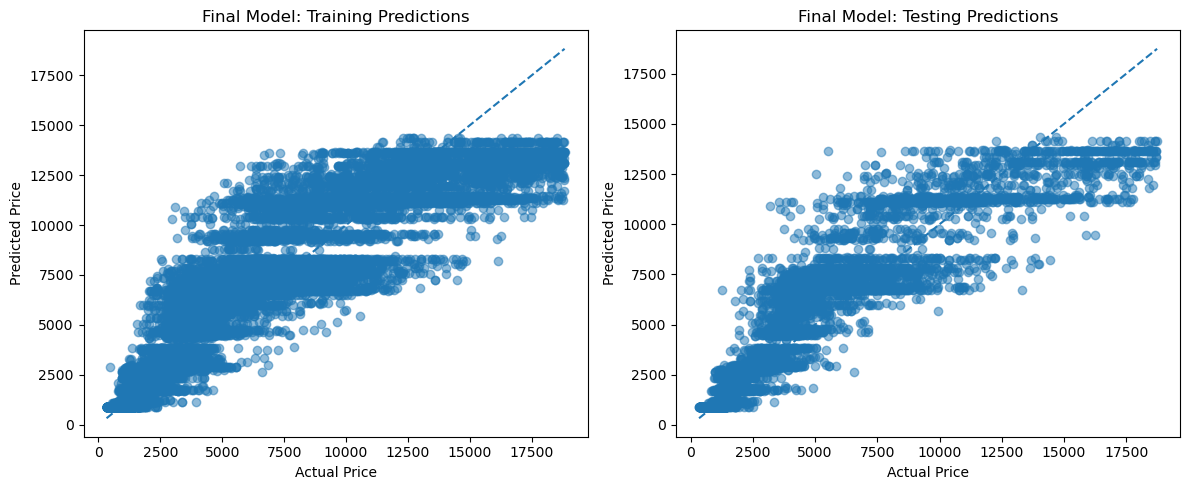

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_train, f_train_pred, alpha=0.5)
train_minimum = min(y_train.min(), f_train_pred.min()); train_maximum = max(y_train.max(), f_train_pred.max())
axes[0].plot([train_minimum, train_maximum], [train_minimum, train_maximum], linestyle='--')
axes[0].set_xlabel('Actual Price'); axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Final Model: Training Predictions')
axes[1].scatter(y_test, f_test_pred, alpha=0.5)
test_minimum = min(y_test.min(), f_test_pred.min()); test_maximum = max(y_test.max(), f_test_pred.max())
axes[1].plot([test_minimum, test_maximum], [test_minimum, test_maximum], linestyle='--')
axes[1].set_xlabel('Actual Price'); axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Final Model: Testing Predictions')
plt.tight_layout()
plt.show()

## **Task 16**
- *Plot the actual and predicted diamond prices for the first 50 testing records using the final AdaBoost model*

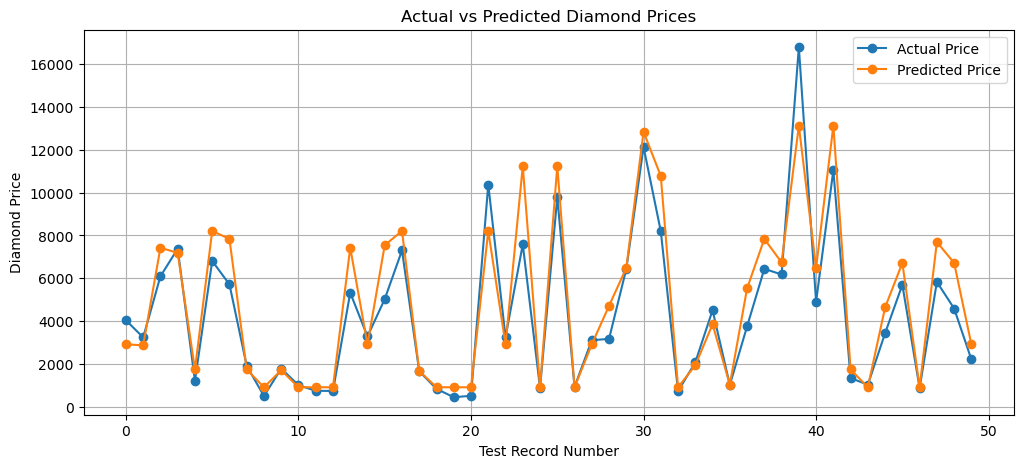

In [28]:
actual_prices = y_test.reset_index(drop = True)[:50]; predicted_prices = f_test_pred[:50]
plt.figure(figsize = (12, 5))
plt.plot(actual_prices, marker = 'o', label = 'Actual Price')
plt.plot(predicted_prices, marker = 'o', label = 'Predicted Price')
plt.xlabel('Test Record Number'); plt.ylabel('Diamond Price')
plt.title('Actual vs Predicted Diamond Prices')
plt.legend()
plt.grid()
plt.show()

## **Task 17**
- *Evaluate the final model using MSE, MAE, RMSE, MAPE, and R² score for the training and testing datasets*

In [29]:
f_train_mse = mean_squared_error(y_train, f_train_pred); f_test_mse = mean_squared_error(y_test, f_test_pred)
f_train_mae = mean_absolute_error(y_train, f_train_pred); f_test_mae = mean_absolute_error(y_test, f_test_pred)
f_train_rmse = np.sqrt(f_train_mse); f_test_rmse = np.sqrt(f_test_mse)
f_train_mape = mean_absolute_percentage_error(y_train, f_train_pred) * 100; f_test_mape = mean_absolute_percentage_error(y_test, f_test_pred) * 100
f_train_r2 = r2_score(y_train, f_train_pred); f_test_r2 = r2_score(y_test, f_test_pred)

print('Final Training MSE:', round(f_train_mse, 2)); print('Final Testing MSE:', round(f_test_mse, 2))
print('\nFinal Training MAE:', round(f_train_mae, 2)); print('Final Testing MAE:', round(f_test_mae, 2))
print('\nFinal Training RMSE:', round(f_train_rmse, 2)); print('Final Testing RMSE:', round(f_test_rmse, 2))
print('\nFinal Training MAPE:', round(f_train_mape, 2), '%'); print('Final Testing MAPE:', round(f_test_mape, 2), '%')
print('\nFinal Training R² Score:', round(f_train_r2, 3)); print('Final Testing R² Score:', round(f_test_r2, 3))

Final Training MSE: 2156147.63
Final Testing MSE: 2183864.89

Final Training MAE: 933.64
Final Testing MAE: 938.08

Final Training RMSE: 1468.38
Final Testing RMSE: 1477.79

Final Training MAPE: 29.01 %
Final Testing MAPE: 29.21 %

Final Training R² Score: 0.865
Final Testing R² Score: 0.859


## **Task 18**
- *Calculate the training–testing performance gap of the final AdaBoost model using the selected evaluation metric*

In [24]:
f_rmse_gap = abs(f_test_rmse - f_train_rmse)
print('Final RMSE Gap:', round(f_rmse_gap, 2))

Final RMSE Gap: 9.41


# Model Comparison

## **Task 19**
- *Compare the training and testing performance of the baseline and final AdaBoost models using MSE, MAE, RMSE, MAPE, R² Score*
- *Create a DataFrame to compare the selected performance gap of the baseline and final AdaBoost models*

In [25]:
comparison = pd.DataFrame({'Model': ['Baseline', 'Baseline', 'Final', 'Final'], 'Dataset': ['Training', 'Testing', 'Training', 'Testing'],
                           'MSE': [b_train_mse, b_test_mse, f_train_mse, f_test_mse],
                           'MAE': [b_train_mae, b_test_mae, f_train_mae, f_test_mae],
                           'RMSE': [b_train_rmse, b_test_rmse, f_train_rmse, f_test_rmse],
                           'MAPE (%)': [b_train_mape, b_test_mape, f_train_mape, f_test_mape],
                           'R² Score': [b_train_r2, b_test_r2, f_train_r2, f_test_r2],})
comparison.round(3)

,Model,Dataset,MSE,MAE,RMSE,MAPE (%),R² Score
0,Baseline,Training,2484961.762,1106.023,1576.376,41.973,0.844
1,Baseline,Testing,2524837.802,1113.974,1588.974,42.282,0.837
2,Final,Training,2156147.634,933.638,1468.383,29.013,0.865
3,Final,Testing,2183864.885,938.082,1477.791,29.209,0.859


In [26]:
gap_comparison = pd.DataFrame({'Model': ['Baseline Model', 'Final Model'], 'Performance Gap': [b_rmse_gap, f_rmse_gap]})
gap_comparison.round(2)

,Model,Performance Gap
0,Baseline Model,12.60
1,Final Model,9.41
